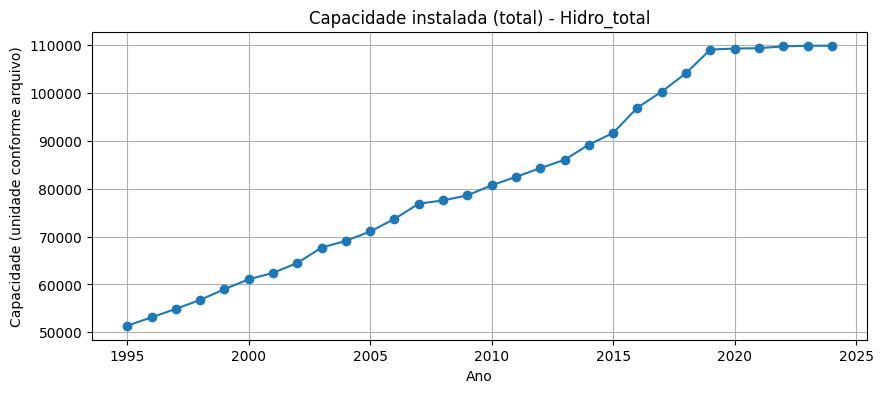

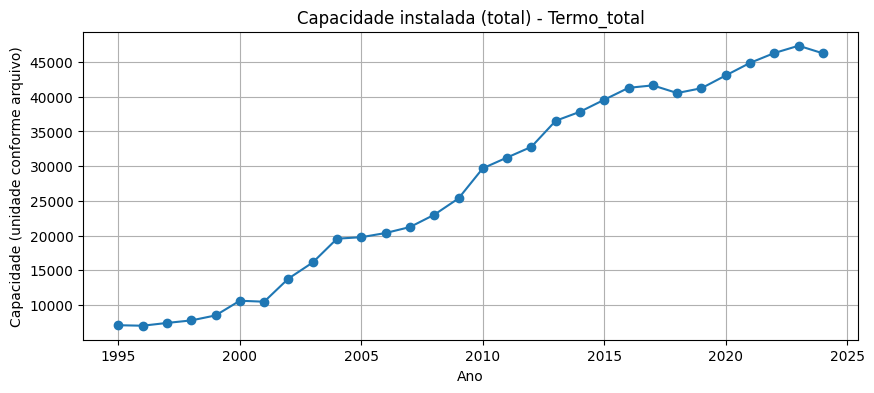

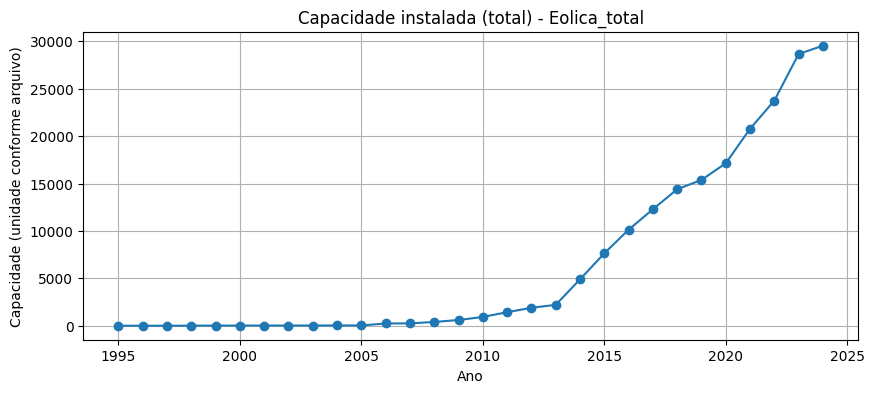

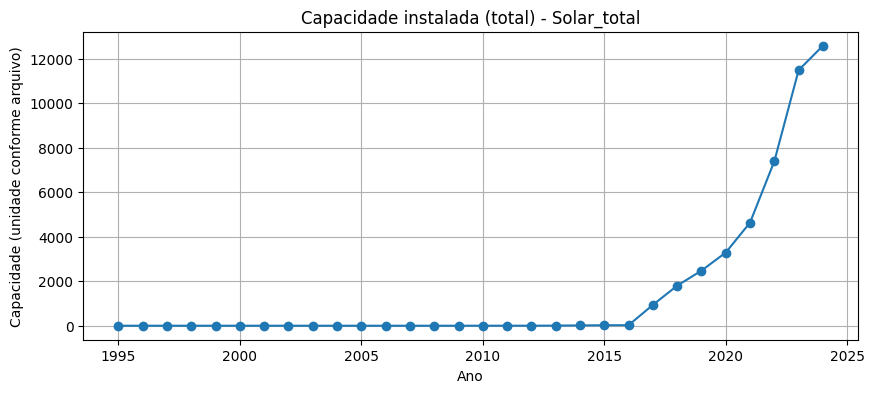

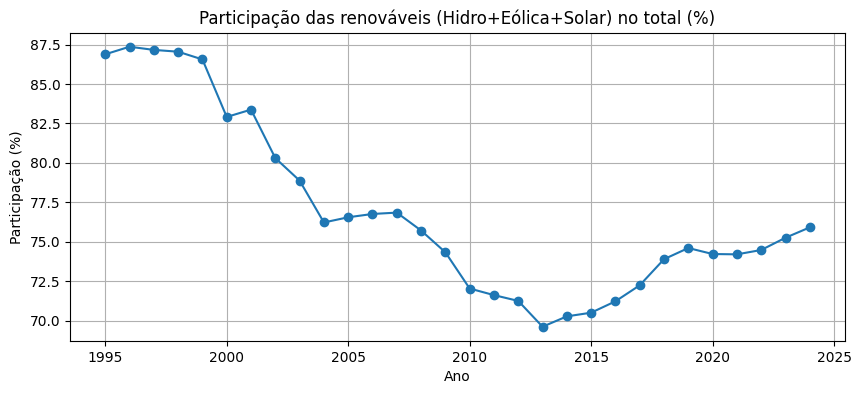

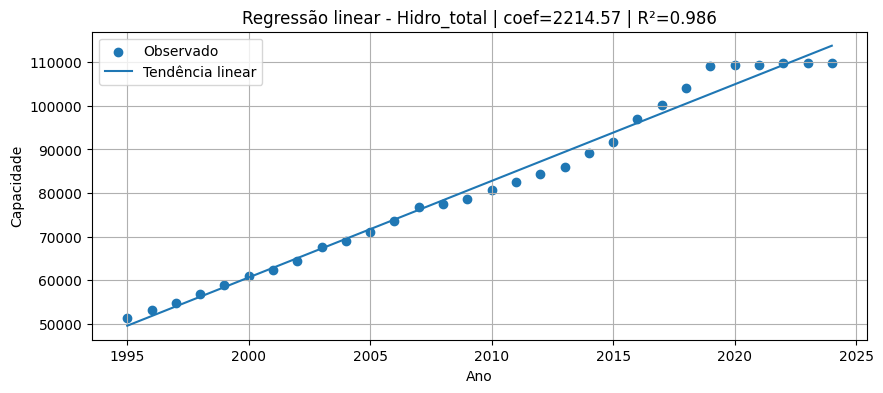

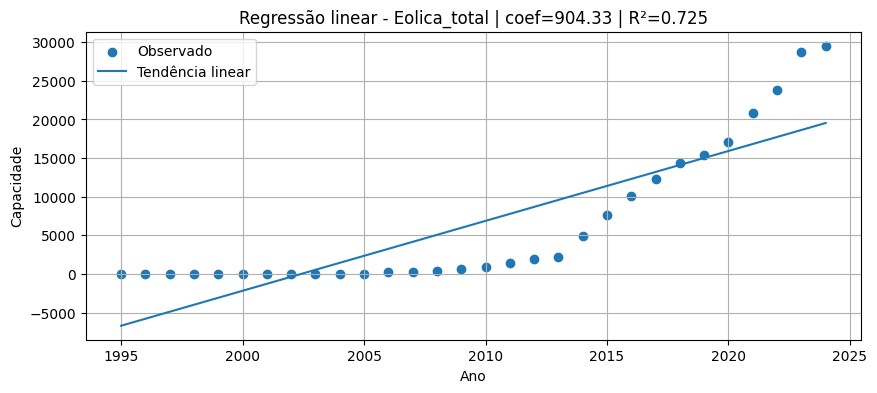

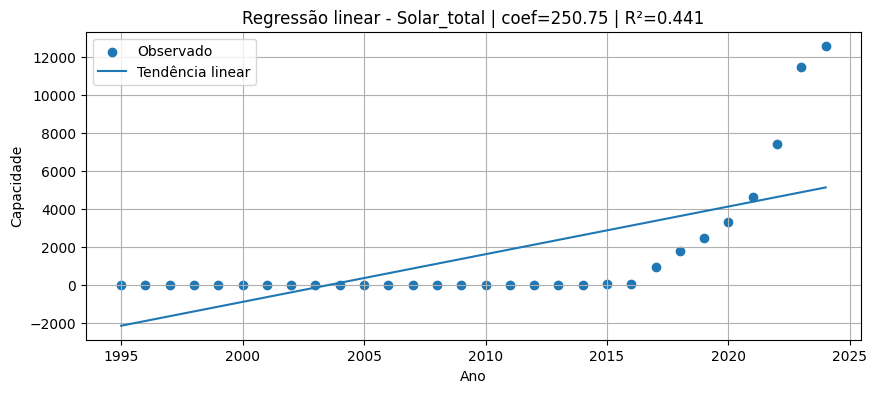

          fonte     coef_ano    intercepto        r2           mse  \
0   Hidro_total  2214.568632 -4.368496e+06  0.986116  5.172961e+06   
1  Eolica_total   904.326363 -1.810823e+06  0.724614  2.328440e+07   
2   Solar_total   250.751057 -5.023964e+05  0.440887  5.973614e+06   

   ultima_capacidade  crescimento_medio_ano  
0           109864.0            2017.137931  
1            29533.0            1018.344828  
2            12576.0             433.655172  


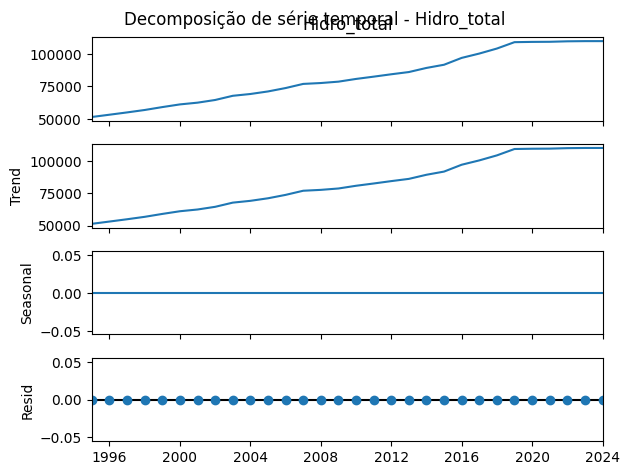

Arquivos salvos em /content/


In [1]:
### Análise 1 Exclusiva Capacidade Instalada EPE BEN
# Fonte ANEXO I BEN CAPACIDADE INSTALADA: https://www.epe.gov.br/pt/publicacoes-dados-abertos/publicacoes/BEN-Series-Historicas-Completas

## 1. Importando as bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# regressões e métricas
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.api as sm

# ## 2. Carregando arquivo
file_path = "/content/Anexo I - Capacidade instalada - GerEnerElet (1).csv"

# ## 3. Ler o CSV como bruto (sem assumir header útil)
raw = pd.read_csv(file_path, header=None, encoding='latin-1')

# ## 4. Filtrar linhas que começam com ano (1900-2100)
def is_year(val):
    try:
        v = str(val).strip()
        return len(v) == 4 and v.isdigit() and 1900 <= int(v) <= 2100
    except:
        return False

year_rows = raw[raw[0].apply(is_year)].copy()
year_rows.reset_index(drop=True, inplace=True)

# ## 5. Mapear colunas (posicionamento observado no arquivo original)
cols_map = {
    'Ano': 0,
    'Hidro_total': 3,
    'Termo_total': 6,
    'Eolica_total': 9,
    'Solar_total': 12,
    'Nuclear': 13,
    'Total_geral': 16
}

# Extrair e converter para numérico (tratando separadores)
parsed = pd.DataFrame()
for name, idx in cols_map.items():
    if idx <= year_rows.shape[1] - 1:
        parsed[name] = pd.to_numeric(year_rows[idx].astype(str).str.replace('.', '').str.replace(',', '.'), errors='coerce')
    else:
        parsed[name] = pd.NA

parsed = parsed.dropna(subset=['Ano']).sort_values('Ano').reset_index(drop=True)

# ## 6. Visualizações (uma figura por gráfico: regra do notebook)
for col in ['Hidro_total', 'Termo_total', 'Eolica_total', 'Solar_total']:
    if col in parsed.columns:
        plt.figure(figsize=(10,4))
        plt.plot(parsed['Ano'], parsed[col], marker='o')
        plt.title(f'Capacidade instalada (total) - {col}')
        plt.xlabel('Ano')
        plt.ylabel('Capacidade (unidade conforme arquivo)')
        plt.grid(True)
        plt.show()

# ## 7. Participação percentual das renováveis (Hidro + Eólica + Solar)
parsed['Renovaveis_total'] = parsed[['Hidro_total','Eolica_total','Solar_total']].sum(axis=1)
parsed['share_renovaveis_pct'] = parsed['Renovaveis_total'] / parsed['Total_geral'] * 100

plt.figure(figsize=(10,4))
plt.plot(parsed['Ano'], parsed['share_renovaveis_pct'], marker='o')
plt.title('Participação das renováveis (Hidro+Eólica+Solar) no total (%)')
plt.xlabel('Ano')
plt.ylabel('Participação (%)')
plt.grid(True)
plt.show()

# ## 8. Modelo de regressão linear por fonte (Ano -> Capacidade)
X = parsed['Ano'].values.reshape(-1,1)
results = []
for col in ['Hidro_total','Eolica_total','Solar_total']:
    if col in parsed.columns:
        y = parsed[col].values
        mask = ~np.isnan(y)
        model = LinearRegression().fit(X[mask], y[mask])
        y_pred = model.predict(X[mask])
        results.append({
            'fonte': col,
            'coef_ano': float(model.coef_[0]),
            'intercepto': float(model.intercept_),
            'r2': float(r2_score(y[mask], y_pred)),
            'mse': float(mean_squared_error(y[mask], y_pred)),
            'ultima_capacidade': float(y[mask][-1]),
            'crescimento_medio_ano': float((y[mask][-1] - y[mask][0])/(mask.sum()-1))
        })
        # plot observado + reta de tendência
        plt.figure(figsize=(10,4))
        plt.scatter(parsed['Ano'], parsed[col], label='Observado')
        plt.plot(parsed['Ano'], model.predict(parsed['Ano'].values.reshape(-1,1)), label='Tendência linear')
        plt.title(f'Regressão linear - {col} | coef={model.coef_[0]:.2f} | R²={r2_score(y[mask], y_pred):.3f}')
        plt.xlabel('Ano')
        plt.ylabel('Capacidade')
        plt.legend()
        plt.grid(True)
        plt.show()

res_df = pd.DataFrame(results)
print(res_df)

# ## 9. Decomposição de série temporal da fonte com maior coeficiente de crescimento
if not res_df.empty:
    top = res_df.sort_values('coef_ano', ascending=False).iloc[0]['fonte']
    ts = parsed.set_index(pd.to_datetime(parsed['Ano'], format='%Y'))[top].asfreq('YS')
    ts_interp = ts.interpolate()
    decomposition = sm.tsa.seasonal_decompose(ts_interp, model='additive', period=1, extrapolate_trend='freq')
    decomposition.plot()
    plt.suptitle(f'Decomposição de série temporal - {top}')
    plt.show()

# ## 10. Salvar resultados
parsed.to_csv("/content/analise_renovaveis_parsed.csv", index=False)
res_df.to_csv("/content/regressao_renovaveis_resultados.csv", index=False)
print("Arquivos salvos em /content/")


Lido com sucesso: encoding=latin-1, sep=';' (shape=(25928, 23))
Colunas detectadas: ['DatGeracaoConjuntoDados', 'NomEmpreendimento', 'IdeNucleoCEG', 'CodCEG', 'SigUFPrincipal', 'SigTipoGeracao', 'DscFaseUsina', 'DscOrigemCombustivel', 'DscFonteCombustivel', 'DscTipoOutorga', 'NomFonteCombustivel', 'DatEntradaOperacao', 'MdaPotenciaOutorgadaKw', 'MdaPotenciaFiscalizadaKw', 'MdaGarantiaFisicaKw', 'IdcGeracaoQualificada', 'NumCoordNEmpreendimento', 'NumCoordEEmpreendimento', 'DatInicioVigencia', 'DatFimVigencia', 'DscPropriRegimePariticipacao', 'DscSubBacia', 'DscMuninicpios']
Coluna de data escolhida: DatEntradaOperacao
Coluna de fonte escolhida: NomFonteCombustivel
Colunas potência (outorgada,fiscalizada): MdaPotenciaOutorgadaKw MdaPotenciaFiscalizadaKw
Coluna nome empreendimento: NomEmpreendimento
Atenção: 3697 linhas com datas fora do intervalo 1950-2025 foram marcadas como NaT.
Valores numéricos não-nulos (Pot_Outorg_kW): 25928
Valores numéricos não-nulos (Pot_Fiscal_kW): 25928
Total

FonteCat,Biomassa/Resíduos,Carvão,Eólica,Gás Natural,Hidrelétrica,Nuclear,Outros,Petróleo,Solar,Total_kW,Renovavel_kW,Participacao_Renovavel_pct
ano,,,,,,,,,,,,
1950,0.0,0.0,0.0,0.0,50824.0,0.0,0.0,0.0,0.0,50824.0,50824.0,100.000000
1951,0.0,0.0,0.0,0.0,92461.0,0.0,0.0,0.0,0.0,92461.0,92461.0,100.000000
1952,0.0,0.0,0.0,0.0,52301.0,0.0,0.0,5000.0,0.0,57301.0,52301.0,91.274149
1953,0.0,0.0,0.0,0.0,398991.0,0.0,0.0,0.0,0.0,398991.0,398991.0,100.000000
1954,40000.0,0.0,0.0,0.0,47009.0,0.0,0.0,285000.0,0.0,372009.0,87009.0,23.388950


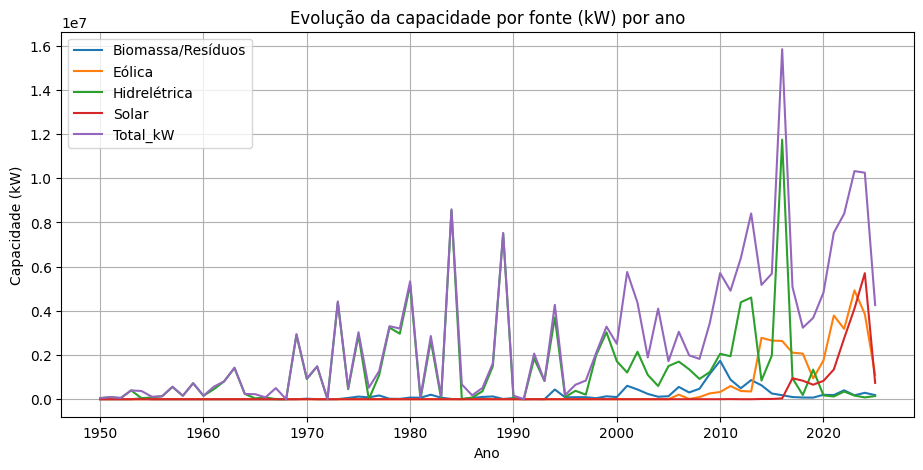

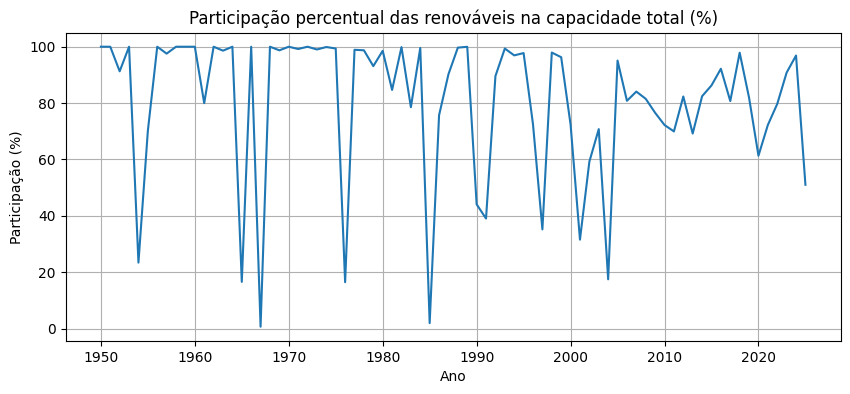

Gráficos salvos em: /content/outputs
Regressão (Renovavel_kW): coef_por_ano=71894.205591, intercept=-140608633.152, R2=0.3342, MSE=4955181170416.223


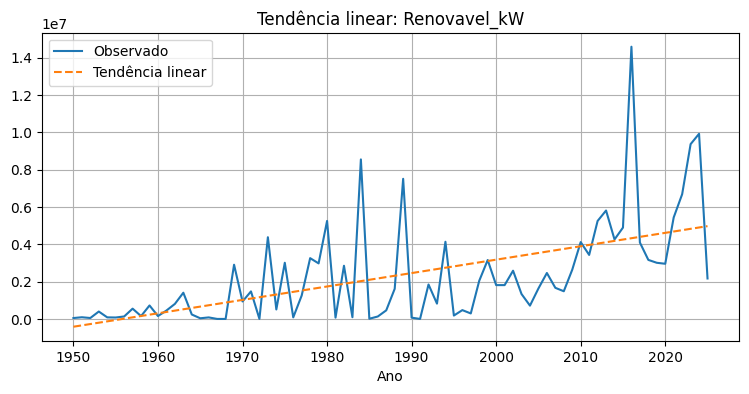

Regressão (Hidrelétrica): coef_por_ano=18408.408913, intercept=-35162030.610, R2=0.0388, MSE=4044926581267.809


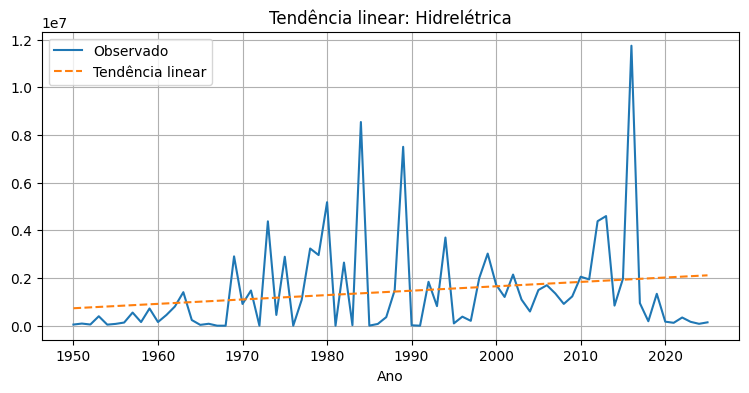

Regressão (Eólica): coef_por_ano=29479.664046, intercept=-58143194.858, R2=0.3750, MSE=696994604826.219


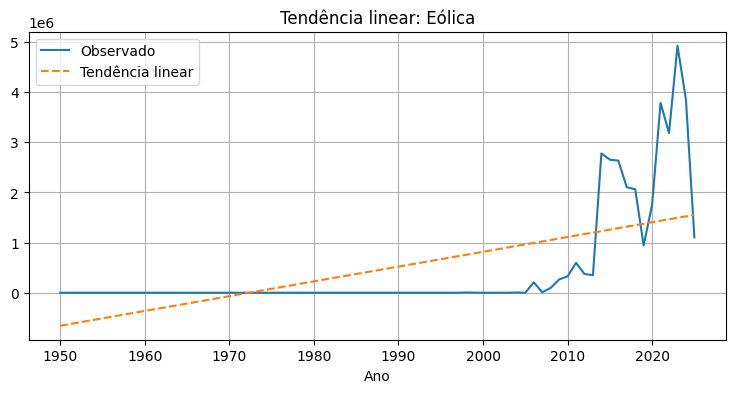

Regressão (Solar): coef_por_ano=17079.440355, intercept=-33708749.496, R2=0.1846, MSE=619926620139.649


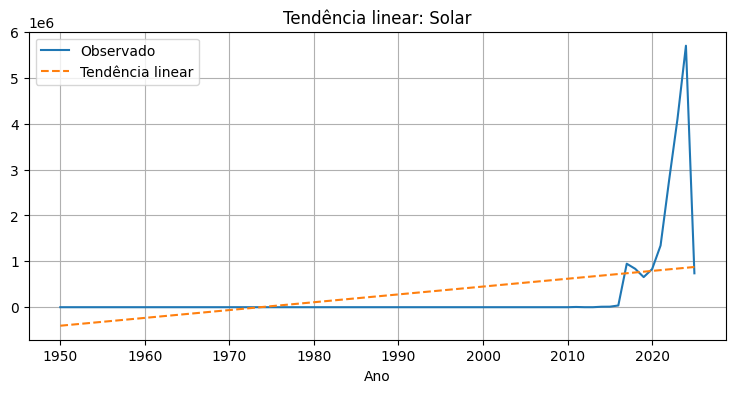

Regressão (Biomassa/Resíduos): coef_por_ano=6926.692276, intercept=-13594658.188, R2=0.2722, MSE=61750989281.042


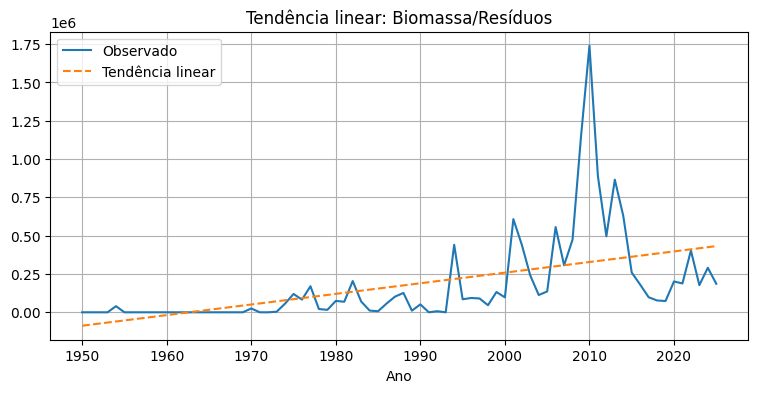

ADF p-value para Renovavel_kW: 0.7986
Melhor ARIMA para Renovavel_kW: order=(0, 1, 1), AIC=2417.38


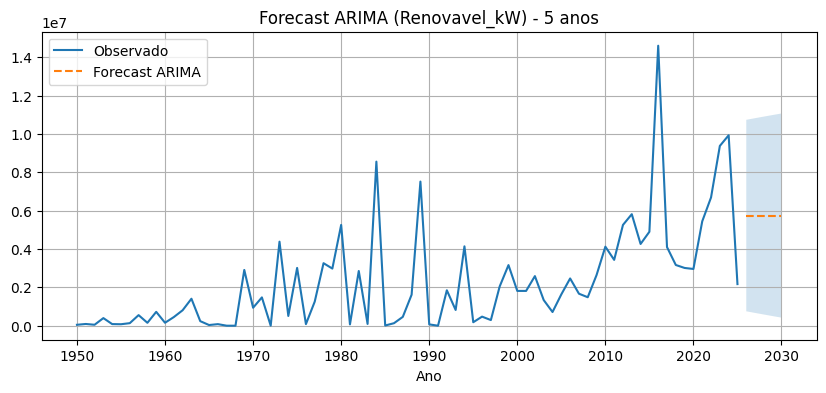

Arquivos finais salvos em: /content/outputs

------
Análise efetuada sobre capacidade instalada (kW) agregada por ano e por fonte.
Foram calculadas tendências lineares e, quando possível, modelos ARIMA para previsão.
Observações e limitações: verifique a qualidade dos campos de potência (Pot_Outorg_kW / Pot_Fiscal_kW).

--- FIM ---


In [2]:
### Análise 2 exclusiva Siga - Empreendimentos Geração:
# Fonte: https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel
## 0. Ajuste o PATH do arquivo se necessário
PATH = r"/content/siga-empreendimentos-geracao (1).csv"   # <-- verifique o nome/exato do arquivo em /content/

## 1. Importando as bibliotecas
import os
import re
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

# Para detectar encoding (se chardet não estiver instalado, instale com !pip install chardet)
try:
    import chardet
except Exception:
    !pip install chardet -q
    import chardet

# Criar pasta de saída
OUTDIR = "/content/outputs"
os.makedirs(OUTDIR, exist_ok=True)

## 2. Funções utilitárias

def read_csv_smart(path, encodings=None, seps=None):
    """Tenta ler o CSV com várias heurísticas de encoding e separador."""
    if encodings is None:
        encodings = ['utf-8','latin-1','iso-8859-1','cp1252']
    if seps is None:
        seps = [',',';','\t','|']
    for enc in encodings:
        for sep in seps:
            try:
                df = pd.read_csv(path, encoding=enc, sep=sep, engine='python')
                if df.shape[1] > 1:
                    print(f"Lido com sucesso: encoding={enc}, sep='{sep}' (shape={df.shape})")
                    return df, enc, sep
            except Exception:
                continue
    # fallback: chardet para detectar encoding, tentar com autodetecção de separador
    raw = open(path, "rb").read()
    guess = chardet.detect(raw)
    enc = guess.get('encoding','latin-1')
    try:
        df = pd.read_csv(path, encoding=enc, engine='python')  # tenta autodetectar separador
        print(f"Lido com chardet: encoding={enc}, sep=autodetect (shape={df.shape})")
        return df, enc, 'autodetect'
    except Exception as e:
        raise IOError(f"Não foi possível ler o CSV com as heurísticas. Erro: {e}")

def get_col_by_keywords(cols, keywords):
    """Retorna a primeira coluna cuja versão lower contém alguma das keywords."""
    cols_l = [c.lower() for c in cols]
    for kw in keywords:
        for i,c in enumerate(cols_l):
            if kw in c:
                return cols[i]
    # se nenhuma encontrada, tentar contains any
    for c in cols:
        if any(kw in c.lower() for kw in keywords):
            return c
    return None

def smart_float(x):
    """Converte strings numéricas que podem usar vírgula como decimal e pontos como separador de milhar."""
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int,float,np.integer,np.floating)):
        return float(x)
    s = str(x).strip()
    if s == "":
        return np.nan
    # remover espaços, símbolos comuns
    s = re.sub(r'[^\d,.\-]', '', s)
    # se tiver tanto '.' quanto ',' -> decidir qual é decimal pelo último separador
    if '.' in s and ',' in s:
        if s.rfind(',') > s.rfind('.'):
            # formato comum em PT-BR: '.' milhares, ',' decimal
            s = s.replace('.', '').replace(',', '.')
        else:
            # caso raro: ',' milhares, '.' decimal
            s = s.replace(',', '')
    else:
        # só vírgula: tratar como decimal
        if ',' in s and '.' not in s:
            s = s.replace(',', '.')
        # só ponto: se houver mais de um ponto, remover pontos (milhares), senão manter
        elif '.' in s and s.count('.') > 1:
            s = s.replace('.', '')
    try:
        return float(s)
    except:
        return np.nan

def categorize_fonte(name):
    if pd.isna(name):
        return 'Desconhecido'
    f = str(name).lower()
    if 'hidro' in f or 'potencial hidráulico' in f or 'hidrául' in f:
        return 'Hidrelétrica'
    if 'vento' in f or 'cinética' in f or 'eólica' in f or 'eol' in f:
        return 'Eólica'
    if 'solar' in f or 'radiação' in f or 'fotovolta' in f:
        return 'Solar'
    if 'biomassa' in f or 'agro' in f or 'resíduos' in f or 'biocomb' in f or 'floresta' in f or 'bagaço' in f:
        return 'Biomassa/Resíduos'
    if 'gás' in f or 'gas' in f:
        return 'Gás Natural'
    if 'petróleo' in f or 'petrole' in f or 'óleo' in f:
        return 'Petróleo'
    if 'carvão' in f or 'carvao' in f:
        return 'Carvão'
    if 'urânio' in f or 'uranio' in f:
        return 'Nuclear'
    return 'Outros'

## 3. Leitura do arquivo
df, used_enc, used_sep = read_csv_smart(PATH)
print("Colunas detectadas:", df.columns.tolist()[:40])

## 4. Normalização inicial e identificação de colunas-chaves
cols = df.columns.tolist()
# Possíveis nomes para data de entrada em operação e data de geração
date_col = get_col_by_keywords(cols, ['datentradaoperacao','dataentrada','dat_ent','datgeracao','datgeracaoconjuntodados','data'])
print("Coluna de data escolhida:", date_col)

fonte_col = get_col_by_keywords(cols, ['nomfontecombustivel','dscfontecombustivel','nomfonte','fontecombustivel','nomfonte'])
print("Coluna de fonte escolhida:", fonte_col)

pot_outorg_col = get_col_by_keywords(cols, ['mdapotenciaoutorgadakw','potenciaoutorgada','mdaoutorgada','potencia_outorgada','potenciaoutorgadakw'])
pot_fiscal_col = get_col_by_keywords(cols, ['mdapotenciafiscalizadakw','potenciafiscalizada','potencia_fiscalizada','mda_fiscalizada'])

print("Colunas potência (outorgada,fiscalizada):", pot_outorg_col, pot_fiscal_col)

# Coluna do nome do empreendimento (para contagem)
nome_col = get_col_by_keywords(cols, ['nomempreendimento','nom_empreendimento','nomedoempreendimento','nomempreend'])
print("Coluna nome empreendimento:", nome_col)

## 5. Conversão de datas
if date_col is None:
    raise KeyError("Não foi possível identificar coluna de data automaticamente. Atualize PATH ou os nomes das colunas.")
df[date_col] = pd.to_datetime(df[date_col], dayfirst=True, errors='coerce')
# Filtrar anos plausíveis (1950 - 2025)
mask_year = df[date_col].dt.year.between(1950, 2025)
invalid_dates = df[~mask_year][date_col].shape[0]
if invalid_dates > 0:
    print(f"Atenção: {invalid_dates} linhas com datas fora do intervalo 1950-2025 foram marcadas como NaT.")
df.loc[~mask_year, date_col] = pd.NaT

## 6. Normalizar/limpar coluna de fonte e categorizar
if fonte_col is None:
    raise KeyError("Não foi possível identificar coluna de fonte (NomFonteCombustivel / DscFonteCombustivel).")
df['Fonte_raw'] = df[fonte_col].astype(str).replace('nan','').replace('None','').str.strip()
df['FonteCat'] = df['Fonte_raw'].apply(categorize_fonte)

## 7. Converter potencia para numérico (se existirem)
if pot_outorg_col is not None:
    df['Pot_Outorg_kW_raw'] = df[pot_outorg_col]
    df['Pot_Outorg_kW'] = df['Pot_Outorg_kW_raw'].apply(smart_float)
else:
    df['Pot_Outorg_kW'] = np.nan

if pot_fiscal_col is not None:
    df['Pot_Fiscal_kW_raw'] = df[pot_fiscal_col]
    df['Pot_Fiscal_kW'] = df['Pot_Fiscal_kW_raw'].apply(smart_float)
else:
    df['Pot_Fiscal_kW'] = np.nan

# Informar contagens
print("Valores numéricos não-nulos (Pot_Outorg_kW):", df['Pot_Outorg_kW'].notna().sum())
print("Valores numéricos não-nulos (Pot_Fiscal_kW):", df['Pot_Fiscal_kW'].notna().sum())

## 8. Preparar dataframe anual (usar DatEntradaOperacao)
df_year = df.dropna(subset=[date_col]).copy()
df_year['ano'] = df_year[date_col].dt.year.astype(int)

## 9. Decidir: capacidade (kW) ou contagem de empreendimentos
cap_nonnull = df_year['Pot_Outorg_kW'].notna().sum() + df_year['Pot_Fiscal_kW'].notna().sum()
print("Total de registros com algum valor de potência:", cap_nonnull)

use_capacity = cap_nonnull >= 5  # limiar para tentar análises de capacidade
if use_capacity:
    print("Será usada análise por CAPACIDADE (kW) onde disponível.")
else:
    print("Campos de potência insuficientes -> será usada ANÁLISE POR CONTAGEM DE EMPREENDIMENTOS.")

## 10. Agregação anual por fonte
renewable_set = ['Hidrelétrica','Eólica','Solar','Biomassa/Resíduos']
if use_capacity:
    # preferir Pot_Fiscal_kW se disponível, senão Pot_Outorg_kW
    df_year['Pot_kW'] = df_year['Pot_Fiscal_kW'].fillna(df_year['Pot_Outorg_kW'])
    agg = df_year.groupby(['ano','FonteCat'])['Pot_kW'].sum().reset_index()
    pivot = agg.pivot(index='ano', columns='FonteCat', values='Pot_kW').fillna(0)
    pivot['Total_kW'] = pivot.sum(axis=1)
    pivot['Renovavel_kW'] = pivot[[c for c in pivot.columns if c in renewable_set]].sum(axis=1)
    pivot['Participacao_Renovavel_pct'] = pivot['Renovavel_kW'] / pivot['Total_kW'] * 100
    pivot.to_csv(os.path.join(OUTDIR,'pivot_capacidade_ano_fonte.csv'))
    print("Pivot de capacidade salvo em:", os.path.join(OUTDIR,'pivot_capacidade_ano_fonte.csv'))
else:
    # contagem de empreendimentos por ano e fonte
    agg = df_year.groupby(['ano','FonteCat'])[nome_col].nunique().reset_index(name='n_empreendimentos')
    pivot = agg.pivot(index='ano', columns='FonteCat', values='n_empreendimentos').fillna(0)
    pivot['Total_empreendimentos'] = pivot.sum(axis=1)
    pivot.to_csv(os.path.join(OUTDIR,'pivot_count_empreendimentos_ano_fonte.csv'))
    print("Pivot de contagens salvo em:", os.path.join(OUTDIR,'pivot_count_empreendimentos_ano_fonte.csv'))

display(pivot.head())

## 11. Gráficos principais (salvar em /content/outputs)
plt.close('all')
if use_capacity:
    # linhas por fonte renovável + total
    fig, ax = plt.subplots(figsize=(11,5))
    cols_to_plot = [c for c in pivot.columns if c in renewable_set] + (['Total_kW'] if 'Total_kW' in pivot.columns else [])
    for c in cols_to_plot:
        ax.plot(pivot.index, pivot[c], label=c)
    ax.set_title('Evolução da capacidade por fonte (kW) por ano')
    ax.set_xlabel('Ano'); ax.set_ylabel('Capacidade (kW)')
    ax.legend(); ax.grid(True)
    fig.savefig(os.path.join(OUTDIR,'capacidade_por_fonte.png'), dpi=150)
    plt.show()

    # participação renovável
    if 'Participacao_Renovavel_pct' in pivot.columns:
        fig, ax = plt.subplots(figsize=(10,4))
        ax.plot(pivot.index, pivot['Participacao_Renovavel_pct'])
        ax.set_title('Participação percentual das renováveis na capacidade total (%)')
        ax.set_xlabel('Ano'); ax.set_ylabel('Participação (%)'); ax.grid(True)
        fig.savefig(os.path.join(OUTDIR,'participacao_renovavel_pct.png'), dpi=150)
        plt.show()
else:
    fig, ax = plt.subplots(figsize=(11,5))
    for c in pivot.columns:
        if c != 'Total_empreendimentos':
            ax.plot(pivot.index, pivot[c], label=c)
    ax.set_title('Número de empreendimentos por fonte (por ano)')
    ax.set_xlabel('Ano'); ax.set_ylabel('Número de empreendimentos')
    ax.legend(); ax.grid(True)
    fig.savefig(os.path.join(OUTDIR,'empreendimentos_por_fonte.png'), dpi=150)
    plt.show()

    fig, ax = plt.subplots(figsize=(10,4))
    ax.plot(pivot.index, pivot['Total_empreendimentos'])
    ax.set_title('Total de empreendimentos por ano')
    ax.set_xlabel('Ano'); ax.set_ylabel('Número de empreendimentos'); ax.grid(True)
    fig.savefig(os.path.join(OUTDIR,'total_empreendimentos_por_ano.png'), dpi=150)
    plt.show()

print("Gráficos salvos em:", OUTDIR)

## 12. Regressão Linear de tendência e interpretação rápida
def safe_filename(name):
    """Sanitiza nomes de arquivo substituindo caracteres problemáticos por '_' """
    return re.sub(r'[^a-zA-Z0-9_-]', '_', str(name))

def run_linear_trend(series, label):
    # series: pd.Series indexed por ano
    if series.dropna().shape[0] < 2:
        print(f"Não há observações suficientes para regressão em {label}.")
        return None
    X = np.array(series.index).reshape(-1,1)
    y = series.values.reshape(-1,1)
    lr = LinearRegression().fit(X,y)
    y_pred = lr.predict(X)
    mse = mean_squared_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    print(f"Regressão ({label}): coef_por_ano={float(lr.coef_[0][0]):.6f}, intercept={float(lr.intercept_[0]):.3f}, R2={r2:.4f}, MSE={mse:.3f}")
    # plot
    fig, ax = plt.subplots(figsize=(9,4))
    ax.plot(series.index, series.values, label='Observado')
    ax.plot(series.index, y_pred.flatten(), linestyle='--', label='Tendência linear')
    ax.set_title(f'Tendência linear: {label}')
    ax.set_xlabel('Ano'); ax.grid(True); ax.legend()
    fname = f"regressao_trend_{safe_filename(label)}.png"
    fig.savefig(os.path.join(OUTDIR, fname), dpi=150)
    plt.show()
    return {'coef':float(lr.coef_[0][0]), 'intercept':float(lr.intercept_[0]), 'r2':r2, 'mse':mse}

results = {}
if use_capacity:
    # tendência da capacidade renovável total
    if 'Renovavel_kW' in pivot.columns:
        results['trend_renovavel_kW'] = run_linear_trend(pivot['Renovavel_kW'], 'Renovavel_kW')
    # e por fonte renovável
    for f in renewable_set:
        if f in pivot.columns:
            results[f] = run_linear_trend(pivot[f], f)
else:
    # tendência no total de empreendimentos
    if 'Total_empreendimentos' in pivot.columns:
        results['trend_total_empreend'] = run_linear_trend(pivot['Total_empreendimentos'], 'Total_empreendimentos')
    # e por fonte (contagem)
    for c in pivot.columns:
        if c != 'Total_empreendimentos':
            results[c] = run_linear_trend(pivot[c], f'Count_{c}')

## 13. Modelagem ARIMA (série anual) - só se houver observações suficientes
def try_arima(series, max_p=3, max_q=3, min_obs=10):
    s = series.dropna()
    if s.shape[0] < min_obs:
        print(f"ARIMA: menos de {min_obs} observações em série '{series.name}' -> pulando.")
        return None
    # testar estacionariedade
    try:
        adf_res = adfuller(s.values)
        print(f"ADF p-value para {series.name}: {adf_res[1]:.4f}")
    except Exception as e:
        print("Erro ADF:", e)
        adf_res = (np.nan, np.nan)
    d = 0 if (not np.isnan(adf_res[1]) and adf_res[1] < 0.05) else 1
    best_aic = np.inf
    best_ord = None
    best_model = None
    for p in range(0, max_p+1):
        for q in range(0, max_q+1):
            try:
                m = ARIMA(s, order=(p,d,q)).fit()
                if m.aic < best_aic:
                    best_aic = m.aic
                    best_ord = (p,d,q)
                    best_model = m
            except Exception:
                continue
    if best_model is None:
        print("Não foi possível ajustar ARIMA para", series.name)
        return None
    print(f"Melhor ARIMA para {series.name}: order={best_ord}, AIC={best_aic:.2f}")
    return {'model': best_model, 'order': best_ord, 'aic': best_aic}

arima_results = {}
# escolher série alvo (capacidade renovável total ou total empreendimentos)
if use_capacity and 'Renovavel_kW' in pivot.columns:
    arima_results['Renovavel_kW'] = try_arima(pivot['Renovavel_kW'].astype(float), max_p=2, max_q=2, min_obs=10)
else:
    if 'Total_empreendimentos' in pivot.columns:
        arima_results['Total_empreendimentos'] = try_arima(pivot['Total_empreendimentos'].astype(float), max_p=2, max_q=2, min_obs=10)

# Se houver modelo ARIMA ajustado, gerar forecast simples
for name, info in arima_results.items():
    if info is None:
        continue
    m = info['model']
    steps = 5
    try:
        fc = m.get_forecast(steps=steps)
        fc_mean = fc.predicted_mean
        fc_ci = fc.conf_int()
        # montar índice futuro (anos consecutivos)
        last_year = int(pivot.index.max())
        future_index = list(range(last_year+1, last_year+1+steps))
        fig, ax = plt.subplots(figsize=(10,4))
        ax.plot(pivot.index, pivot[name], label='Observado')
        ax.plot(future_index, fc_mean, linestyle='--', label='Forecast ARIMA')
        ax.fill_between(future_index, fc_ci.iloc[:,0], fc_ci.iloc[:,1], alpha=0.2)
        ax.set_title(f'Forecast ARIMA ({name}) - {steps} anos')
        ax.set_xlabel('Ano'); ax.legend(); ax.grid(True)
        fig.savefig(os.path.join(OUTDIR,f'forecast_arima_{name}.png'), dpi=150)
        plt.show()
    except Exception as e:
        print("Erro ao prever com ARIMA:", e)

## 14. Salvar resultados resumidos
pd.DataFrame({'info': [f'Arquivo lido: {PATH}', f'encoding: {used_enc}', f'separador: {used_sep}']}).to_csv(os.path.join(OUTDIR,'meta_info.csv'), index=False)
if use_capacity:
    pivot.to_csv(os.path.join(OUTDIR,'pivot_capacidade_ano_fonte_final.csv'))
else:
    pivot.to_csv(os.path.join(OUTDIR,'pivot_contagem_ano_fonte_final.csv'))
print("Arquivos finais salvos em:", OUTDIR)

## 15. Texto redigido pós análise
def resumo_(use_capacity, pivot, results):
    if use_capacity:
        txt = (
            "Análise efetuada sobre capacidade instalada (kW) agregada por ano e por fonte.\n"
            "Foram calculadas tendências lineares e, quando possível, modelos ARIMA para previsão.\n"
            "Observações e limitações: verifique a qualidade dos campos de potência (Pot_Outorg_kW / Pot_Fiscal_kW).\n"
        )
    else:
        txt = (
            "Devido à ausência/insuficiência de campos de potência no dataset, a análise utilizou o número\n"
            "de empreendimentos com data de entrada em operação por ano como proxy para a difusão das tecnologias.\n"
            "Esta métrica identifica a dinâmica de adoção por fonte (ex.: crescimento de projetos solares/eólicos),\n"
            "mas não substitui uma análise por capacidade (kW) ou geração (MWh), pois projetos têm tamanhos distintos.\n"
            "Recomenda-se complementar o dataset com os campos de potência ou séries de geração para análises quantitativas.\n"
        )
    return txt

print("\n------")
print(resumo_(use_capacity, pivot, results))
print("--- FIM ---")

Período: 2000-2025
Total adicionado (kW): 140,315,568 kW
Total renovável adicionado (kW): 111,014,580 kW
Participação renovável cumulativa final: 79.12%

Regressão (participação cumulativa ~ ano):
                             OLS Regression Results                            
Dep. Variable:     renewable_share_cum   R-squared:                       0.754
Model:                             OLS   Adj. R-squared:                  0.744
Method:                  Least Squares   F-statistic:                     73.64
Date:                 Sun, 14 Sep 2025   Prob (F-statistic):           8.92e-09
Time:                         05:37:58   Log-Likelihood:                 38.592
No. Observations:                   26   AIC:                            -73.18
Df Residuals:                       24   BIC:                            -70.67
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
   

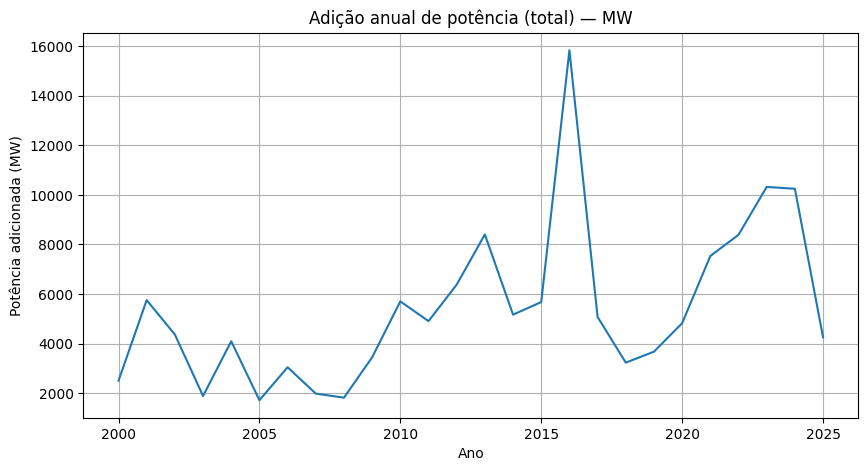

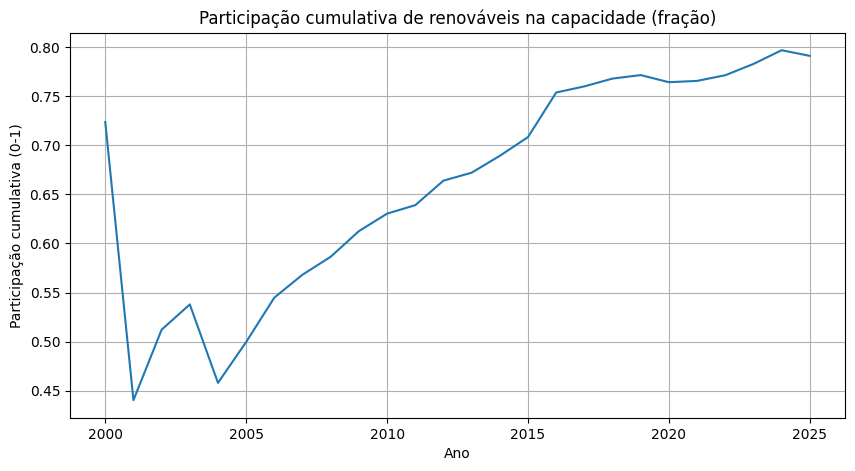

Agregação salva em: /content/annual_aggregation_renewables.csv


In [3]:
## Regressão com a base da Aneel
## 0) Importando bibliotecas necessárias

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.seasonal import STL

# 1) Ajustando o caminho do CSV para o arquivo
PATH = '/content/siga-empreendimentos-geracao (1).csv'  # ajuste conforme necessário

# 2) Leitura robusta (tenta detectar separador e usa latin-1 se houver acentuação)
df = pd.read_csv(PATH, engine='python', sep=None, encoding='latin-1')

# 3) Normalizações e conversões de potência (kW)
def to_numeric_kW(x):
    if pd.isna(x): return np.nan
    s = str(x).replace('.', '').replace(',', '.')
    s = re.sub(r'[^\d\.]', '', s)
    try:
        return float(s)
    except:
        return np.nan

df['pot_kw'] = df['MdaPotenciaFiscalizadaKw'].astype(object).apply(to_numeric_kW)
mask = df['pot_kw'].isna()
df.loc[mask, 'pot_kw'] = df.loc[mask, 'MdaPotenciaOutorgadaKw'].astype(object).apply(to_numeric_kW)

# 4) Datas: parse e filtrar a partir de 2000
df['dat_entrada'] = pd.to_datetime(df['DatEntradaOperacao'], dayfirst=True, errors='coerce')
df = df[df['dat_entrada'].notna()].copy()
df['year_entrada'] = df['dat_entrada'].dt.year
df = df[df['year_entrada'] >= 2000].copy()
df['year_entrada'] = df['year_entrada'].astype(int)

# 5) Classificação renovável (ajuste keywords conforme necessário)
df['origem_clean'] = df['DscOrigemCombustivel'].astype(str).str.strip()
renewable_origins = ['Hídrica','Eólica','Solar','Biomassa']
df['is_renewable'] = df['origem_clean'].isin(renewable_origins)
df['fonte_clean'] = df['DscFonteCombustivel'].astype(str).str.lower()
# busca por palavras em 'fonte' quando 'origem' não informar
df.loc[df['is_renewable'] == False, 'is_renewable'] = df.loc[df['is_renewable'] == False, 'fonte_clean'].str.contains(
    'hidrául|potencial hidráulico|eólica|vento|solar|biomassa|floresta|resíduos|agro|biocombust', na=False)

# 6) Agregação anual (kW)
annual = df.groupby('year_entrada').agg(
    total_added_kw = ('pot_kw', 'sum'),
    renewable_added_kw = ('pot_kw', lambda x: x[df.loc[x.index, 'is_renewable']].sum())
).reset_index().set_index('year_entrada')

years = list(range(2000, df['year_entrada'].max() + 1))
annual = annual.reindex(years, fill_value=0).rename_axis('year').reset_index()
annual['cum_total_kw'] = annual['total_added_kw'].cumsum()
annual['cum_renewable_kw'] = annual['renewable_added_kw'].cumsum()
annual['renewable_share_cum'] = annual['cum_renewable_kw'] / annual['cum_total_kw']
annual['renewable_share_annual'] = (annual['renewable_added_kw'] / annual['total_added_kw']).fillna(0)

# 7) Estatísticas rápidas
total_added = annual['total_added_kw'].sum()
renew_added = annual['renewable_added_kw'].sum()
final_share = annual['renewable_share_cum'].iloc[-1]
print(f"Período: {annual['year'].min()}-{annual['year'].max()}")
print(f"Total adicionado (kW): {total_added:,.0f} kW")
print(f"Total renovável adicionado (kW): {renew_added:,.0f} kW")
print(f"Participação renovável cumulativa final: {final_share:.2%}")

# 8) Regressões
# 8.1 Participação cumulativa ~ ano
ann_reg = annual[annual['cum_total_kw']>0].copy()
X = sm.add_constant(ann_reg['year'])
y = ann_reg['renewable_share_cum'].astype(float)
model = sm.OLS(y, X, missing='drop').fit()
print("\nRegressão (participação cumulativa ~ ano):")
print(model.summary())

# 8.2 log(adição renovável anual) ~ ano  -> crescimento médio das adições
ann_reg2 = annual.copy()
ann_reg2['renewable_added_kw_pos'] = ann_reg2['renewable_added_kw'].clip(lower=1)  # evitar log(0)
X2 = sm.add_constant(ann_reg2['year'])
y2 = np.log(ann_reg2['renewable_added_kw_pos']).astype(float)
model2 = sm.OLS(y2, X2, missing='drop').fit()
coef2 = model2.params['year']
growth_rate = np.exp(coef2) - 1
print("\nRegressão (log(adição renovável) ~ ano):")
print(model2.summary())
print(f"Estimativa de crescimento médio das adições renováveis ≈ {growth_rate:.2%} ao ano")

# 9) Gráficos (matplotlib)
plt.figure(figsize=(10,5))
plt.plot(annual['year'], annual['total_added_kw']/1e3)  # em MW
plt.title('Adição anual de potência (total) — MW')
plt.xlabel('Ano')
plt.ylabel('Potência adicionada (MW)')
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
plt.plot(annual['year'], annual['renewable_share_cum'])
plt.title('Participação cumulativa de renováveis na capacidade (fração)')
plt.xlabel('Ano')
plt.ylabel('Participação cumulativa (0-1)')
plt.grid(True)
plt.show()

# 10) Exportar agregação (download)
annual.to_csv('/content/annual_aggregation_renewables.csv', index=False)
print("Agregação salva em: /content/annual_aggregation_renewables.csv")


[leitura OK] /content/siga-empreendimentos-geracao (1).csv (encoding=latin-1, engine=python) => shape (25928, 23)
[leitura OK] /content/Anexo I - Capacidade instalada - GerEnerElet (1).csv (encoding=latin-1, engine=python) => shape (39, 17)

--- Processando arquivo de empreendimentos ---
Agregação anual (projetos) salva em /content/annual_from_projects.csv

--- Processando arquivo ANEXO de capacidade ---

Usando agregação de projetos para análises (ano x adições).

--- Regressão: participação renovável ~ ano ---
                            OLS Regression Results                            
Dep. Variable:        renewable_share   R-squared:                       0.171
Model:                            OLS   Adj. R-squared:                  0.137
Method:                 Least Squares   F-statistic:                     4.962
Date:                Sun, 14 Sep 2025   Prob (F-statistic):             0.0355
Time:                        05:38:00   Log-Likelihood:                 9.5261
No. Obse

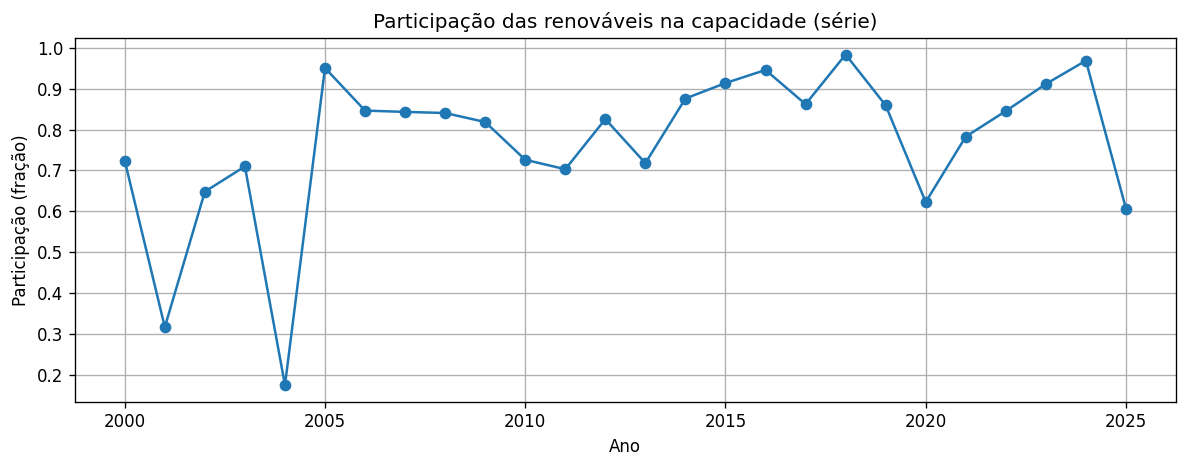

Salvo: /content/capacidade_renovavel_por_ano.png


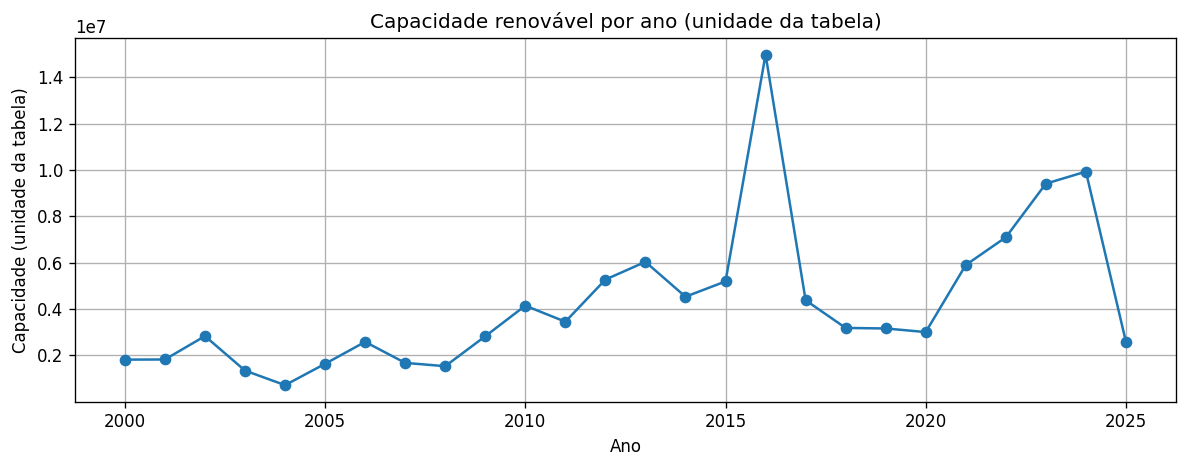

Salvo: /content/adicao_anual_renovavel.png


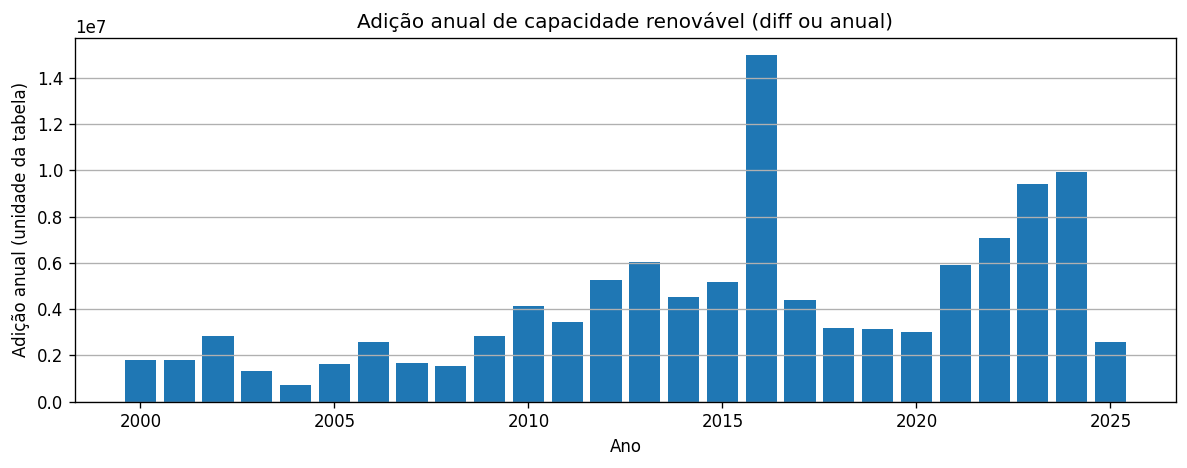

Salvo: /content/stl_trend_adicao_renovavel.png


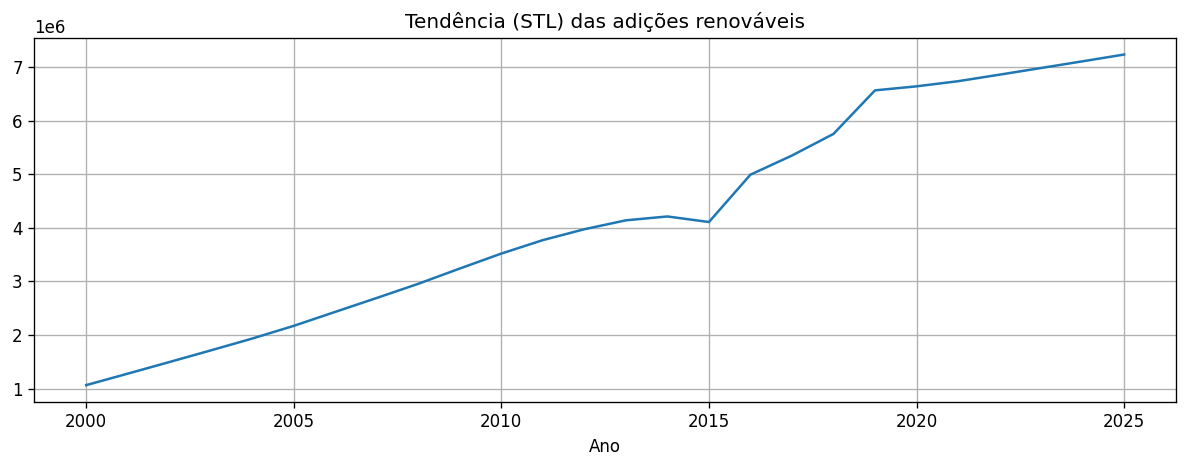

Série final salva em /content/serie_renovaveis_por_ano_final.csv
Resumo das regressões salvo em /content/regressions_summary.txt

--- Observações finais ---
1) Eu carreguei os arquivos disponíveis e tentei detectar automaticamente o formato.
2) Eu normalizei valores e construí séries por ano; verifique a unidade (MW/GW) no arquivo original.
3) A regressão linear da participação ao longo do tempo e a regressão logarítmica das adições fornecem uma visão inicial do ritmo de transição.
4) Use as saídas CSV e os PNG gerados para incluir em relatórios; se quiser eu monto um PDF com texto e figuras.

Arquivos gerados (no ambiente):
 - /content/serie_renovaveis_por_ano_final.csv
 - /content/participacao_renovavel_por_ano.png
 - /content/capacidade_renovavel_por_ano.png
 - /content/adicao_anual_renovavel.png
 - /content/regressions_summary.txt
 - /content/stl_trend_adicao_renovavel.png


In [4]:
## Combinando as bases para uma análise conjunta e mais robusta
# 0) Imports e configurações iniciais
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.seasonal import STL
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120

# 1) Caminhos dos arquivos para analisar projetos e capacidade juntos
PATH_PROJECTS = '/content/siga-empreendimentos-geracao (1).csv'   # arquivo de empreendimentos (opcional)
PATH_ANNEX    = '/content/Anexo I - Capacidade instalada - GerEnerElet (1).csv'  # anexo de capacidade (opcional)

# 2) Funções utilitárias
def try_read_csv(path):
    """Tento ler o CSV com heurísticas de encoding/sep."""
    for enc in ['latin-1', 'utf-8', 'cp1252']:
        for engine in ['python', 'c']:
            try:
                # sep=None + engine='python' faz sniff do separador; engine='c' com sep=',' padrão
                if engine == 'python':
                    df = pd.read_csv(path, engine='python', sep=None, encoding=enc)
                else:
                    df = pd.read_csv(path, engine='c', encoding=enc)
                print(f"[leitura OK] {path} (encoding={enc}, engine={engine}) => shape {df.shape}")
                return df
            except Exception as e:
                # não interrompo, tento outra combinação
                pass
    raise RuntimeError(f"Não consegui ler o CSV: {path} — verifique encoding/sep manualmente.")

def parse_potencia_to_numeric(x):
    """Converte strings numéricas com separador de milhares e vírgula decimal para float."""
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    # substituir espaços, normalizar vírgula para ponto
    s = re.sub(r'\s+', '', s)
    s = s.replace(',', '.')
    # remover quaisquer caracteres não numéricos exceto ponto e sinal negativo
    s = re.sub(r'[^0-9\.\-]', '', s)
    if s == '' or s == '-' or s == '.':
        return np.nan
    try:
        return float(s)
    except:
        return np.nan

def identify_renewable_columns(cols):
    """Heurística simples para identificar colunas de fontes renováveis."""
    renew_kw = ['hidro','eol','eolica','eólica','eolico','eólico','solar','biomass','biomassa','bio','residu']
    renew = [c for c in cols if any(k in str(c).lower() for k in renew_kw)]
    return renew

def identify_nonrenewable_columns(cols):
    nonrenew_kw = ['term','gas','coal','carv','petr','petro','oleo','óleo','nuclear','nuclea']
    nonrenew = [c for c in cols if any(k in str(c).lower() for k in nonrenew_kw)]
    return nonrenew

# 3) Carregar arquivos (os dois são opcionais)
df_projects = None
df_annex = None
try:
    df_projects = try_read_csv(PATH_PROJECTS)
except Exception as e:
    print("Arquivo de empreendimentos não carregado automaticamente:", e)

try:
    df_annex = try_read_csv(PATH_ANNEX)
except Exception as e:
    print("Arquivo anexo de capacidade não carregado automaticamente:", e)

# -----------------------------------------------------------
# 4) Se houver arquivo de empreendimentos (ex.: siga-empreendimentos...) eu processo para obter agregação por ano a partir de DatEntradaOperacao, usando potências em MdaPotenciaFiscalizadaKw / MdaPotenciaOutorgadaKw
# -----------------------------------------------------------
annual_from_projects = None
if isinstance(df_projects, pd.DataFrame):
    print("\n--- Processando arquivo de empreendimentos ---")
    df = df_projects.copy()
    # normalizar nomes de colunas (trim)
    df.columns = [c.strip() for c in df.columns]
    # converter potencia: tentar MdaPotenciaFiscalizadaKw e MdaPotenciaOutorgadaKw
    pot_cols = ['MdaPotenciaFiscalizadaKw', 'MdaPotenciaOutorgadaKw', 'MdaGarantiaFisicaKw']
    found_pot_col = None
    for c in pot_cols:
        if c in df.columns:
            found_pot_col = c
            break
    # criar coluna pot_kw combinando colunas candidatas
    df['pot_kw'] = np.nan
    if 'MdaPotenciaFiscalizadaKw' in df.columns:
        df['pot_kw'] = df['MdaPotenciaFiscalizadaKw'].apply(parse_potencia_to_numeric)
    if df['pot_kw'].isna().all() and 'MdaPotenciaOutorgadaKw' in df.columns:
        df['pot_kw'] = df['MdaPotenciaOutorgadaKw'].apply(parse_potencia_to_numeric)
    else:
        mask = df['pot_kw'].isna() & df.get('MdaPotenciaOutorgadaKw', pd.Series()).notna()
        if mask.any():
            df.loc[mask, 'pot_kw'] = df.loc[mask, 'MdaPotenciaOutorgadaKw'].apply(parse_potencia_to_numeric)

    # parse de datas de entrada em operação
    if 'DatEntradaOperacao' in df.columns:
        df['dat_entrada'] = pd.to_datetime(df['DatEntradaOperacao'], dayfirst=True, errors='coerce')
    else:
        # tentar outras colunas parecidas
        possible = [c for c in df.columns if 'entrada' in c.lower() or 'operacao' in c.lower()]
        if possible:
            df['dat_entrada'] = pd.to_datetime(df[possible[0]], dayfirst=True, errors='coerce')
        else:
            df['dat_entrada'] = pd.NaT

    # extrair ano e filtrar >= 2000
    df['year_entrada'] = df['dat_entrada'].dt.year
    df = df[df['year_entrada'].notna()]
    df = df[df['year_entrada'] >= 2000].copy()
    df['year_entrada'] = df['year_entrada'].astype(int)

    # classificar renovável por DscOrigemCombustivel / DscFonteCombustivel quando disponíveis
    df['origem_clean'] = df.get('DscOrigemCombustivel', '').astype(str).str.strip()
    renewable_origins = ['Hídrica','Eólica','Solar','Biomassa','Hidrica','Eolica']
    df['is_renewable'] = df['origem_clean'].isin(renewable_origins)
    # inferência por DscFonteCombustivel
    if 'DscFonteCombustivel' in df.columns:
        df['fonte_clean'] = df['DscFonteCombustivel'].astype(str).str.lower()
        mask = (~df['is_renewable']) & df['fonte_clean'].notna()
        df.loc[mask, 'is_renewable'] = df.loc[mask, 'fonte_clean'].str.contains(
            'hidrául|potencial hidráulico|eólica|vento|solar|biomassa|floresta|resíduos|agro|biocombust', regex=True, na=False)

    # Agregação anual em kW
    annual = df.groupby('year_entrada').agg(
        total_added_kw = ('pot_kw','sum'),
        renewable_added_kw = ('pot_kw', lambda x: x[df.loc[x.index,'is_renewable']].sum() )
    ).reset_index().set_index('year_entrada')

    # preencher anos sem observação
    years = list(range(2000, df['year_entrada'].max()+1))
    annual = annual.reindex(years, fill_value=0).rename_axis('year').reset_index()
    annual['nonrenewable_added_kw'] = annual['total_added_kw'] - annual['renewable_added_kw']
    annual['cum_total_kw'] = annual['total_added_kw'].cumsum()
    annual['cum_renewable_kw'] = annual['renewable_added_kw'].cumsum()
    annual['renewable_share_cum'] = annual['cum_renewable_kw'] / annual['cum_total_kw']
    annual_from_projects = annual.copy()
    # salvar CSV
    annual.to_csv('/content/annual_from_projects.csv', index=False)
    print("Agregação anual (projetos) salva em /content/annual_from_projects.csv")

# -----------------------------------------------------------
# 5) Se houver um arquivo anexo de capacidade (formato wide com anos nas linhas), tentarei reconstruir uma tabela year x fonte a partir dele.
# -----------------------------------------------------------
pivot_annex = None
series_by_annex = None
if isinstance(df_annex, pd.DataFrame):
    print("\n--- Processando arquivo ANEXO de capacidade ---")
    df0 = df_annex.copy().reset_index(drop=True)

    # Tento encontrar a linha onde os anos começam (heurística: linha com '1990'..'2025')
    year_row_idx = None
    for i in range(0, min(8, df0.shape[0])):  # inspecionar primeiras linhas
        row = ' '.join(df0.iloc[i].astype(str).tolist()).lower()
        if any(str(y) in row for y in range(1990, 2031)):
            year_row_idx = i
            break

    # Caso comum: cabeçalho está em 2 linhas; detecto e construo novos nomes de colunas agrupando dois níveis
    if year_row_idx is None:
        # fallback: assumo que as linhas 0..3 contêm rótulos; uso a linha 4 em diante como dados
        year_row_idx = 2

    # Procurar a linha a partir da qual os dados numéricos realmente começam (linha contendo o ano 1995, 2000 etc.)
    data_start_idx = None
    for i in range(year_row_idx, min(year_row_idx+6, df0.shape[0])):
        # se na primeira célula houver um ano válido, assumo data a partir dessa linha+?
        try:
            vals = df0.iloc[i].astype(str).tolist()
            if any(re.fullmatch(r'\s*20\d{2}\s*', v) or re.fullmatch(r'\s*19\d{2}\s*', v) for v in vals):
                data_start_idx = i
                break
        except:
            pass
    # se achei a linha de dados, tento reconstruir cabeçalho e tabela
    if data_start_idx is None:
        data_start_idx = year_row_idx + 2

    # Muitas tabelas de anexo vêm com cabeçalhos nas linhas anteriores; eu tento combinar uma das primeiras linhas para formar nomes
    header_candidates = df0.iloc[max(0, data_start_idx-3):data_start_idx].fillna('').astype(str)
    # construir colunas a partir da última linha header (mais provável)
    new_cols = header_candidates.iloc[-1].tolist()
    data = df0.iloc[data_start_idx:].copy().reset_index(drop=True)
    data.columns = new_cols

    # Normalizar: transformar primeira coluna em 'year' (quando essa coluna contém números de ano)
    first_col = data.columns[0]
    data = data.rename(columns={first_col: 'year'})
    # converter 'year' para numeric
    data['year'] = pd.to_numeric(data['year'], errors='coerce').astype('Int64')
    data = data.dropna(subset=['year']).copy()
    data['year'] = data['year'].astype(int)

# Converter demais colunas numéricas com heurística
for c in data.columns[1:]:
    col = data[c]

    # Se for DataFrame (colunas duplicadas), pega só a primeira
    if isinstance(col, pd.DataFrame):
        col = col.iloc[:, 0]

    # Converte para string, limpa e volta para número
    col = col.astype(str).fillna("")
    col = col.str.replace(r'\s+', '', regex=True)       # remove espaços
    col = col.str.replace(',', '.', regex=False)        # vírgula → ponto
    col = col.str.replace(r'[^\d\.\-]', '', regex=True) # só números, ponto e sinal

    data[c] = pd.to_numeric(col, errors='coerce')


    # Detectar colunas de fonte por palavras-chave (hidro, eol, solar, termo, nuclear)
    cols = data.columns.tolist()
    renewable_cols = identify_renewable_columns(cols)
    nonrenewable_cols = identify_nonrenewable_columns(cols)

    # Se a tabela já for pivot (colunas = fontes e linhas = anos), uso diretamente
    pivot_annex = data.set_index('year').sort_index()
    # Calcular somas para renováveis / não renováveis conforme heurística
    pivot_annex['renewable_kw'] = pivot_annex[renewable_cols].sum(axis=1) if renewable_cols else 0.0
    pivot_annex['nonrenewable_kw'] = pivot_annex[nonrenewable_cols].sum(axis=1) if nonrenewable_cols else 0.0
    # tentar extrair total da própria tabela (coluna que contenha 'total' no nome)
    total_cols = [c for c in pivot_annex.columns if 'total' in str(c).lower()]
if total_cols:
    # soma todas as colunas que tenham "total" no nome
    pivot_annex['total_kw_calc'] = pivot_annex[total_cols].sum(axis=1)
else:
    pivot_annex['total_kw_calc'] = pivot_annex[renewable_cols + nonrenewable_cols].sum(axis=1)

    pivot_annex['renewable_share'] = pivot_annex['renewable_kw'] / pivot_annex['total_kw_calc']
    series_by_annex = pivot_annex.copy()
    # Salvar CSV
    series_by_annex.reset_index().to_csv('/content/serie_renovaveis_por_ano_from_annex.csv', index=False)
    print("Série por ano (anexo) salva em /content/serie_renovaveis_por_ano_from_annex.csv")

# -----------------------------------------------------------
# 6) Unificar saídas e rodar análises finais (seleciono a fonte disponível com maior cobertura)
# -----------------------------------------------------------
# Prioridade: uso series_by_annex se disponível (provém tabela por ano x fonte), senão uso annual_from_projects (agreg. por ano a partir de projetos)
if series_by_annex is not None:
    series = series_by_annex.copy()
    print("\nUsando série derivada do ANEXO para análises (ano x fontes).")
elif annual_from_projects is not None:
    # transformar annual_from_projects para formato semelhante (index year)
    series = annual_from_projects.copy().set_index('year')
    # aqui 'total_added_kw' representa adições por ano (kW); transformo colunas para nomes consistentes
    series = series.rename(columns={'total_added_kw':'total_kw', 'renewable_added_kw':'renewable_kw'})
    # se total_kw não estiver presente, use cum_total? já temos total_added_kw
    if 'total_kw' not in series.columns:
        series['total_kw'] = series['cum_total_kw']
    series['total_kw_calc'] = series['total_kw']
    series['renewable_share'] = series['renewable_kw'] / series['total_kw_calc']
    print("\nUsando agregação de projetos para análises (ano x adições).")
else:
    raise RuntimeError("Nenhuma fonte de série anual encontrada — carregue ao menos um dos arquivos e rode novamente.")

# Limpar índices com NaN e ordenar anos
series = series[~series.index.isna()].sort_index()
series.index = series.index.astype(int)

# Tratar casos zeros/NaN
series['total_kw_calc'] = series['total_kw_calc'].replace(0, np.nan)
series['renewable_share'] = series['renewable_share'].astype(float)

# 7) Regressões: participação renovável ~ ano
df_reg = series.reset_index().rename(columns={'index':'year'}) if 'year' not in series.reset_index().columns else series.reset_index()
if 'renewable_share' not in df_reg.columns:
    df_reg['renewable_share'] = series.get('renewable_share', np.nan).values

df_reg = df_reg.dropna(subset=['renewable_share', series.index.name if series.index.name else 'year'], how='any')
# garantir coluna 'year'
if 'year' not in df_reg.columns:
    df_reg['year'] = series.index

X = sm.add_constant(df_reg['year'])
y = df_reg['renewable_share'].astype(float)
model_share = sm.OLS(y, X, missing='drop').fit()
print("\n--- Regressão: participação renovável ~ ano ---")
print(model_share.summary())

# 8) Análises de adições (ano-a-ano) e regressão log
# Definir série de adições de renováveis: se série representa capacidade instalada acumulada, faço diff; se representa adições anuais, uso direto.
renew_series = series.get('renewable_kw', None)
total_series = series.get('total_kw_calc', None)

# Heurística de cumulativo: se série for quase monotonic crescente -> provavelmente cumulativa
def is_cumulative(s):
    s = s.dropna()
    if len(s) < 3:
        return False
    return s.is_monotonic_increasing

if renew_series is None:
    raise RuntimeError("Não encontro coluna 'renewable_kw' na série para calcular adições.")

if is_cumulative(renew_series):
    renew_add = renew_series.diff().fillna(renew_series.iloc[0])
else:
    renew_add = renew_series.copy()  # já parece ser quantidade por ano

# regressão log(renew_add) ~ year
ann = pd.DataFrame({'year': renew_add.index, 'renew_add': renew_add.values}).dropna()
ann['renew_add_pos'] = ann['renew_add'].clip(lower=1)  # evitar log(0)
X2 = sm.add_constant(ann['year'])
y2 = np.log(ann['renew_add_pos']).astype(float)
model_log = sm.OLS(y2, X2, missing='drop').fit()
coef_year_log = model_log.params.get('year', np.nan)
growth_rate_approx = np.exp(coef_year_log) - 1 if not np.isnan(coef_year_log) else np.nan

print("\n--- Regressão: log(adição renovável anual) ~ ano ---")
print(model_log.summary())
print(f"Estimativa de crescimento médio aproximado (exp(coef)-1): {growth_rate_approx:.4f} ({growth_rate_approx*100:.2f}% a.a.)")

# 9) Decomposição STL da série de adições (se length suficiente)
try:
    if len(ann) >= 6:
        stl = STL(ann.set_index('year')['renew_add_pos'].replace(0,np.nan).interpolate(), period=5, robust=True).fit()
        stl_trend = stl.trend
        stl_seasonal = stl.seasonal
        stl_resid = stl.resid
    else:
        stl = None
        stl_trend = None
except Exception as e:
    stl = None
    stl_trend = None
    print("STL falhou:", e)

# 10) Gráficos: eu gosto de salvar figuras em PNG para relatório
def save_fig(fig, path):
    fig.savefig(path, bbox_inches='tight', dpi=200)
    print("Salvo:", path)

# Gráfico 1: participação renovável por ano
fig1, ax1 = plt.subplots(figsize=(10,4))
ax1.plot(series.index, series['renewable_share'], marker='o')
ax1.set_title("Participação das renováveis na capacidade (série)")
ax1.set_xlabel("Ano"); ax1.set_ylabel("Participação (fração)")
ax1.grid(True)
plt.tight_layout()
save_fig(fig1, '/content/participacao_renovavel_por_ano.png')
plt.show()

# Gráfico 2: capacidade renovável por ano (unidade original)
fig2, ax2 = plt.subplots(figsize=(10,4))
ax2.plot(series.index, series['renewable_kw'], marker='o')
ax2.set_title("Capacidade renovável por ano (unidade da tabela)")
ax2.set_xlabel("Ano"); ax2.set_ylabel("Capacidade (unidade da tabela)")
ax2.grid(True)
plt.tight_layout()
save_fig(fig2, '/content/capacidade_renovavel_por_ano.png')
plt.show()

# Gráfico 3: adição anual renovável (diff ou valores diretos)
fig3, ax3 = plt.subplots(figsize=(10,4))
ax3.bar(ann['year'], ann['renew_add'])
ax3.set_title("Adição anual de capacidade renovável (diff ou anual)")
ax3.set_xlabel("Ano"); ax3.set_ylabel("Adição anual (unidade da tabela)")
ax3.grid(axis='y')
plt.tight_layout()
save_fig(fig3, '/content/adicao_anual_renovavel.png')
plt.show()

# Gráfico 4: tendência STL (se disponível)
if stl is not None:
    fig4, ax4 = plt.subplots(figsize=(10,4))
    ax4.plot(stl_trend.index, stl_trend.values, label='Trend')
    ax4.set_title("Tendência (STL) das adições renováveis")
    ax4.set_xlabel("Ano"); ax4.grid(True)
    plt.tight_layout()
    save_fig(fig4, '/content/stl_trend_adicao_renovavel.png')
    plt.show()

# 11) Salvar saídas CSV (resultados)
series_reset = series.reset_index().rename(columns={'index':'year'}) if 'year' not in series.reset_index().columns else series.reset_index()
# Ajustar colunas relevantes antes de salvar
out_cols = []
if 'renewable_kw' in series.columns:
    out_cols.append('renewable_kw')
if 'nonrenewable_kw' in series.columns:
    out_cols.append('nonrenewable_kw')
if 'total_kw_calc' in series.columns:
    out_cols.append('total_kw_calc')
if 'renewable_share' in series.columns:
    out_cols.append('renewable_share')

series_reset[['year'] + out_cols].to_csv('/content/serie_renovaveis_por_ano_final.csv', index=False)
print("Série final salva em /content/serie_renovaveis_por_ano_final.csv")

# Também salvar resumo das regressões em um TXT simples
with open('/content/regressions_summary.txt', 'w', encoding='utf-8') as f:
    f.write("Regressão: participação renovavel ~ ano\n")
    f.write(str(model_share.summary()))
    f.write("\n\nRegressão: log(adição renovavel) ~ ano\n")
    f.write(str(model_log.summary()))
    f.write(f"\n\nEstimativa crescimento médio (exp(coef)-1): {growth_rate_approx}\n")
print("Resumo das regressões salvo em /content/regressions_summary.txt")

# 12) Observações finais
print("\n--- Observações finais ---")
print("1) Eu carreguei os arquivos disponíveis e tentei detectar automaticamente o formato.")
print("2) Eu normalizei valores e construí séries por ano; verifique a unidade (MW/GW) no arquivo original.")
print("3) A regressão linear da participação ao longo do tempo e a regressão logarítmica das adições fornecem uma visão inicial do ritmo de transição.")
print("4) Use as saídas CSV e os PNG gerados para incluir em relatórios; se quiser eu monto um PDF com texto e figuras.")
print("\nArquivos gerados (no ambiente):")
print(" - /content/serie_renovaveis_por_ano_final.csv")
print(" - /content/participacao_renovavel_por_ano.png")
print(" - /content/capacidade_renovavel_por_ano.png")
print(" - /content/adicao_anual_renovavel.png")
print(" - /content/regressions_summary.txt")
if stl is not None:
    print(" - /content/stl_trend_adicao_renovavel.png")